In [1]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [2]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 12 ms, sys: 3.99 ms, total: 16 ms
Wall time: 15.6 ms
CPU times: user 4.86 ms, sys: 1.98 ms, total: 6.84 ms
Wall time: 6.83 ms
CPU times: user 2.24 ms, sys: 1.03 ms, total: 3.26 ms
Wall time: 3.27 ms


In [3]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [4]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel', 'history_segment'] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history', 'mens', 'womens']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 3 lớp Embedding và 4 lớp Projection.


/tmp/ipykernel_261912/1902134193.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)


In [5]:
epochs = 150
early_stop_metric = "ema_qini"
ema = True
ema_alpha = 0.25
patience = 20
print (f" epochs = {epochs}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")


 epochs = 150
 early stop = ema_qini
 use ema = True
 ema alpha = 0.25
 patience = 20


In [ ]:
import io
import optuna
from contextlib import redirect_stdout, redirect_stderr

# Minimize Optuna console noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Optuna search config (validation only)
seeds = [412312, 42, 1874, 902745, 1]
n_trials = 200
tpe_sampler_seed = 412312
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    grid_lr = trial.suggest_float("lr", 5e-5, 5e-3, log=True)
    grid_wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    grid_outcome_dropout = trial.suggest_float("outcome_dropout", 0.0, 0.7)
    grid_shared_dropout = trial.suggest_float("shared_dropout", 0.0, 0.7)
    grid_shared_hidden = trial.suggest_int("shared_hidden", 32, 500)
    grid_outcome_hidden = trial.suggest_int("outcome_hidden", 32, 500)
    grid_ziln_lambda = trial.suggest_float("ziln_lambda", 1e-4, 0.1, log=True)
    grid_pos_weight = trial.suggest_float("pos_weight", 0.1, 99.0, log=True)
    grid_ema_alpha = trial.suggest_float("ema_alpha", 0.1, 0.4)
    grid_early_stop_start = trial.suggest_int("early_stop_start", 10, 50)


    val_loss_list = []
    for SEED in seeds:
        seed_everything(SEED)

        tarnet = Tarnet(
            cate_dims=cat_dims,
            num_count=num_count,
            epochs=epochs,
            learning_rate=grid_lr,
            weight_decay=grid_wd,
            use_ema=ema,
            ema_alpha=grid_ema_alpha,
            patience=patience,
            shared_hidden=grid_shared_hidden,
            outcome_hidden=grid_outcome_hidden,
            outcome_dropout=grid_outcome_dropout,
            shared_dropout=grid_shared_dropout,
            early_stop_metric="loss",
            early_stop_start_epoch=grid_early_stop_start,
            ziln_lambda=grid_ziln_lambda,
            pos_weight=grid_pos_weight
        )

        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            tarnet.fit(train_loader, val_loader)

        current_val_loss = float(tarnet.best_loss)
        if not np.isfinite(current_val_loss):
            current_val_loss = float(tarnet.validate(val_loader))

        val_loss_list.append(current_val_loss)

    # Calculate aggregated loss across the 5 validation seeds
    mean_val_loss = float(np.mean(val_loss_list))
    std_val_loss = float(np.std(val_loss_list))

    trial.set_user_attr("mean_val_loss", mean_val_loss)
    trial.set_user_attr("std_val_loss", std_val_loss)
    return mean_val_loss

def print_trial_callback(study, trial):
    value = float(trial.value) if trial.value is not None else float("nan")
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

    if not completed_trials:
        print(
            f"Finished trial {trial.number}: val loss: {value:.4f} - "
            f"with hyperparameters: {trial.params} | "
            "best trial: N/A (no completed trials yet)",
            flush=True,
        )
        return

    best_trial = study.best_trial
    best_value = float(best_trial.value) if best_trial.value is not None else float("nan")
    print(
        f"Finished trial {trial.number}: val loss: {value:.4f} - "
        f"with hyperparameters: {trial.params} | "
        f"best trial: {best_trial.number} loss: {best_value:.4f}",
        flush=True,
    )

sampler = optuna.samplers.TPESampler(seed=tpe_sampler_seed)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=n_trials, show_progress_bar=True, callbacks=[print_trial_callback])

trial_rows = []
for t in study.trials:
    if t.value is None:
        continue
    trial_rows.append({
        "trial": t.number,
        "lr": round(float(t.params["lr"]), 4),
        "weight_decay": round(float(t.params["weight_decay"]), 4),
        "shared_hidden": int(t.params["shared_hidden"]),
        "outcome_hidden": int(t.params["outcome_hidden"]),
        "shared_dropout": round(float(t.params["shared_dropout"]), 3),
        "outcome_dropout": round(float(t.params["outcome_dropout"]), 3),
        "ziln_lambda": round(float(t.params["ziln_lambda"]), 3),
        "pos_weight": round(float(t.params["pos_weight"]), 3),
        "ema_alpha": round(float(t.params["ema_alpha"]), 3),
        "early_stop_start": int(t.params["early_stop_start"]),
        "mean_val_loss": float(t.value),
        "std_val_loss": float(t.user_attrs.get("std_val_loss", np.nan))
    })

df_grid = pd.DataFrame(trial_rows).sort_values("mean_val_loss", ascending=True).reset_index(drop=True)
best_params = study.best_params
best_cfg = pd.Series({
    "lr": float(best_params["lr"]),
    "weight_decay": float(best_params["weight_decay"]),
    "shared_hidden": int(best_params["shared_hidden"]),
    "outcome_hidden": int(best_params["outcome_hidden"]),
    "shared_dropout": float(best_params["shared_dropout"]),
    "outcome_dropout": float(best_params["outcome_dropout"]),
    "ziln_lambda": float(best_params["ziln_lambda"]),
    "pos_weight": float(best_params["pos_weight"]),
    "ema_alpha": float(best_params["ema_alpha"]),
    "early_stop_start": int(best_params["early_stop_start"]),
    "mean_val_loss": float(study.best_value),
    "std_val_loss": float(study.best_trial.user_attrs.get("std_val_loss", np.nan))
})

  0%|          | 0/200 [00:00<?, ?it/s]

Finished trial 0: val loss: 1.9754 - with hyperparameters: {'lr': 0.00045041481661314923, 'weight_decay': 3.2543813547868006e-05, 'outcome_dropout': 0.285791981486852, 'shared_dropout': 0.3103695462655224, 'shared_hidden': 314, 'outcome_hidden': 416, 'ziln_lambda': 0.06371867322051755, 'pos_weight': 85.58273522042343, 'ema_alpha': 0.27706978682774963, 'early_stop_start': 40} | best trial: 0 loss: 1.9754


Best trial: 0. Best value: 1.97535:   0%|          | 1/200 [02:21<7:47:41, 141.01s/it]

Finished trial 1: val loss: 1.5115 - with hyperparameters: {'lr': 0.002171714497238471, 'weight_decay': 1.7564582302056362e-05, 'outcome_dropout': 0.2919863338576562, 'shared_dropout': 0.12019291253634456, 'shared_hidden': 133, 'outcome_hidden': 345, 'ziln_lambda': 0.020060756221905698, 'pos_weight': 6.59384117198814, 'ema_alpha': 0.27561798033507484, 'early_stop_start': 31} | best trial: 1 loss: 1.5115


Best trial: 1. Best value: 1.51149:   1%|          | 2/200 [04:16<6:55:17, 125.85s/it]

...

Best trial: 79. Best value: 1.44978:  57%|█████▋    | 114/200 [3:39:27<5:03:23, 211.66s/it]

Finished trial 114: val loss: 1.4532 - with hyperparameters: {'lr': 0.00013417149471344053, 'weight_decay': 9.725334574282646e-05, 'outcome_dropout': 0.044749076592595534, 'shared_dropout': 0.25878689551729317, 'shared_hidden': 39, 'outcome_hidden': 47, 'ziln_lambda': 0.0011720955958609044, 'pos_weight': 0.7312709225341439, 'ema_alpha': 0.27579359409648224, 'early_stop_start': 10} | best trial: 79 loss: 1.4498


Best trial: 79. Best value: 1.44978:  57%|█████▊    | 115/200 [3:42:53<4:57:25, 209.95s/it]

Finished trial 115: val loss: 1.4706 - with hyperparameters: {'lr': 0.00010217706543658965, 'weight_decay': 6.131658041704527e-05, 'outcome_dropout': 0.028721443564054063, 'shared_dropout': 0.34867428524678173, 'shared_hidden': 58, 'outcome_hidden': 57, 'ziln_lambda': 0.001749299636437517, 'pos_weight': 0.10540709887445256, 'ema_alpha': 0.2622454344900972, 'early_stop_start': 12} | best trial: 79 loss: 1.4498


Best trial: 79. Best value: 1.44978:  58%|█████▊    | 116/200 [3:45:37<4:34:34, 196.12s/it]

In [ ]:
from IPython.display import display

if 'study' not in globals():
    print('Run Cell 6 (Optuna tuning) first.')
else:
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best mean_Val_Loss: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")

if 'best_cfg' in globals():
    print('\nBest config table:')
    display(best_cfg.to_frame().T)
else:
    print('\nbest_cfg not found.')

if 'df_grid' in globals():
    print('\nTop 10 trials:')
    display(df_grid.head(10))
else:
    print('\ndf_grid not found.')

if 'df_results' in globals():
    print('\nPer-seed test results:')
    display(df_results)
    print('\nTest metrics mean ± std:')
    display(df_results.drop(columns='Seed').agg(['mean', 'std']))

🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 11
📊 Score Selection Start Epoch: 11 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Loss: 0.0835 | Cls: 0.0823 | Reg: 1.7169 | mu_t: 4.3828 | sigma_t: 1.1058 | mu_c: 4.4404 | sigma_c: 1.0858 | Val Loss: 1.4670 | F1_c: 0.0000 | PR_AUC_c: 0.0064 | F1_t: 0.0000 | PR_AUC_t: 0.0212 | Val Qini: 0.4572 (ignored before score selection start epoch) | LR: 0.001000
Epoch 2/150 | Loss: 0.0757 | Cls: 0.0747 | Reg: 1.3830 | mu_t: 4.3850 | sigma_t: 1.0146 | mu_c: 4.4243 | sigma_c: 0.9720 | Val Loss: 1.4616 | F1_c: 0.0000 | PR_AUC_c: 0.0085 | F1_t: 0.0000 | PR_AUC_t: 0.0278 | Val Qini: 0.2760 (ignored before score selection start epoch) | LR: 0.001000
Epoch 3/150 | Loss: 0.1330 | Cls: 0.1309 | Reg: 2.9168 | mu_t: 4.3349 | sigma_t: 0.9857 | mu_c: 4.3786 | sigma_c: 0.9497 | Val Loss: 1.4617 | F1_c: 0.0000 | PR_AUC_c: 0.0089 | F1_t: 0.074

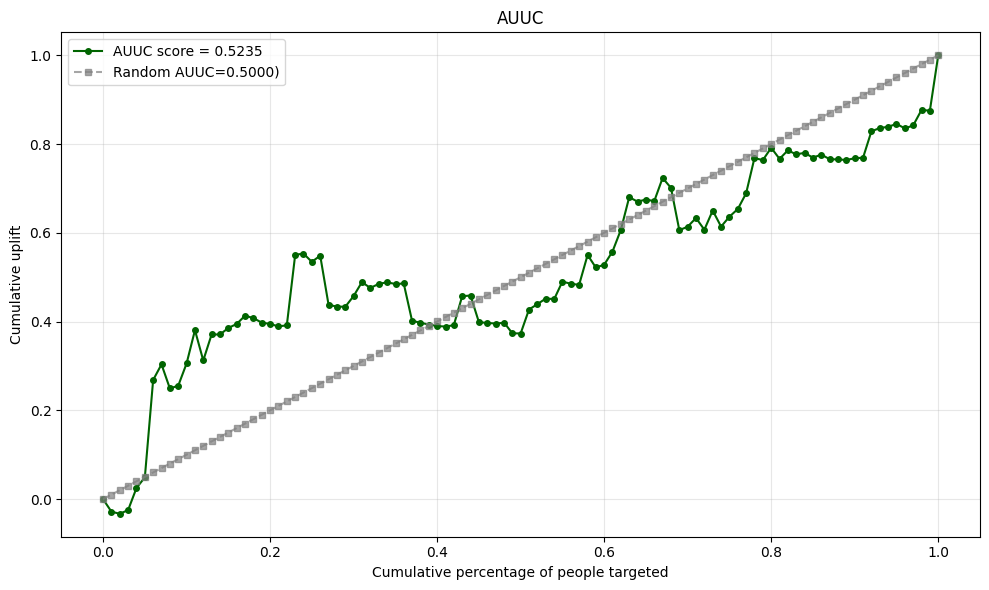

  Done Seed 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 11
📊 Score Selection Start Epoch: 11 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Loss: 0.0867 | Cls: 0.0855 | Reg: 1.7217 | mu_t: 4.3760 | sigma_t: 1.1200 | mu_c: 4.4398 | sigma_c: 1.0279 | Val Loss: 1.4664 | F1_c: 0.0000 | PR_AUC_c: 0.0057 | F1_t: 0.0370 | PR_AUC_t: 0.0222 | Val Qini: 0.6070 (ignored before score selection start epoch) | LR: 0.001000
Epoch 2/150 | Loss: 0.0911 | Cls: 0.0898 | Reg: 1.8365 | mu_t: 4.3519 | sigma_t: 1.0380 | mu_c: 4.4774 | sigma_c: 0.8778 | Val Loss: 1.4579 | F1_c: 0.0000 | PR_AUC_c: 0.0083 | F1_t: 0.0000 | PR_AUC_t: 0.0313 | Val Qini: 0.2972 (ignored before score selection start epoch) | LR: 0.001000
Epoch 3/150 | Loss: 0.1274 | Cls: 0.1256 | Reg: 2.4239 | mu_t: 4.3123 | sigma_t: 1.0035 | mu_c: 4.5119 | sigma_c: 0.8382 | Val Loss: 1.4570 | F1_c: 0.0000 | PR_AUC_c: 0

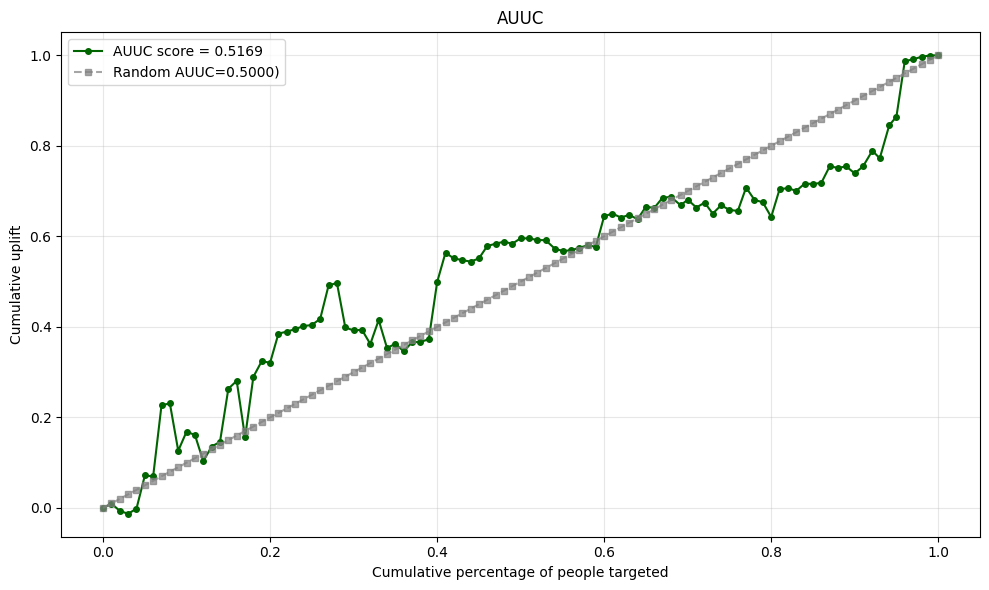

  Done Seed 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 11
📊 Score Selection Start Epoch: 11 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Loss: 0.0577 | Cls: 0.0570 | Reg: 1.0843 | mu_t: 4.3318 | sigma_t: 1.1349 | mu_c: 4.3892 | sigma_c: 0.9955 | Val Loss: 1.4653 | F1_c: 0.0000 | PR_AUC_c: 0.0077 | F1_t: 0.0000 | PR_AUC_t: 0.0266 | Val Qini: 0.3676 (ignored before score selection start epoch) | LR: 0.001000
Epoch 2/150 | Loss: 0.0439 | Cls: 0.0434 | Reg: 0.6289 | mu_t: 4.3460 | sigma_t: 1.0977 | mu_c: 4.3609 | sigma_c: 0.9432 | Val Loss: 1.4630 | F1_c: 0.0000 | PR_AUC_c: 0.0082 | F1_t: 0.0000 | PR_AUC_t: 0.0360 | Val Qini: 0.2282 (ignored before score selection start epoch) | LR: 0.001000
Epoch 3/150 | Loss: 0.1071 | Cls: 0.1057 | Reg: 2.0001 | mu_t: 4.3398 | sigma_t: 1.0548 | mu_c: 4.5092 | sigma_c: 0.7429 | Val Loss: 1.4581 | F1_c: 0.0000 | PR_AUC_c: 0.008

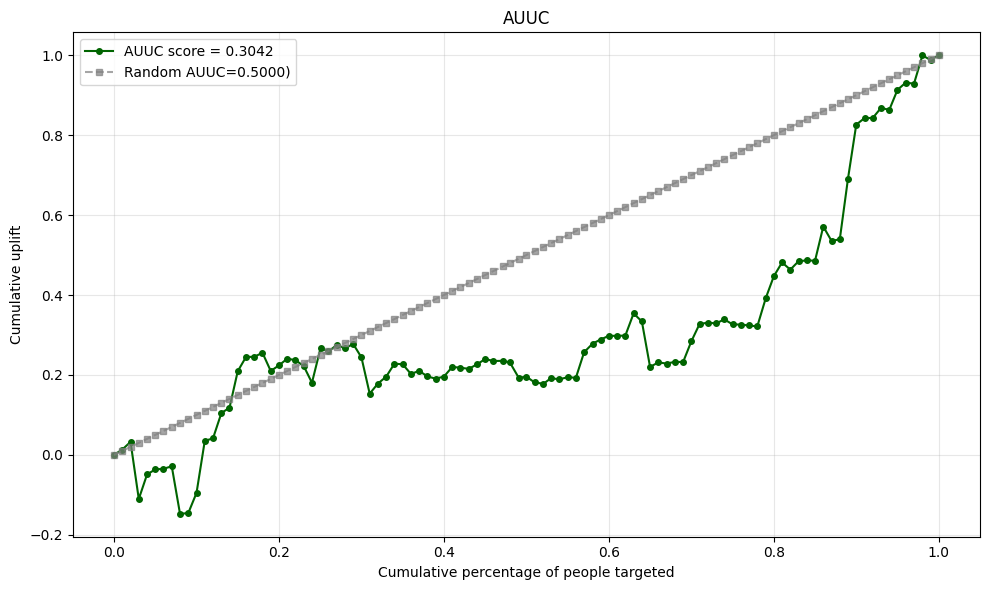

  Done Seed 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 11
📊 Score Selection Start Epoch: 11 (ignore earlier epochs)
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Loss: 0.0718 | Cls: 0.0707 | Reg: 1.5135 | mu_t: 4.3695 | sigma_t: 1.1375 | mu_c: 4.3439 | sigma_c: 0.9135 | Val Loss: 1.4635 | F1_c: 0.0000 | PR_AUC_c: 0.0060 | F1_t: 0.0000 | PR_AUC_t: 0.0168 | Val Qini: 0.3308 (ignored before score selection start epoch) | LR: 0.001000
Epoch 2/150 | Loss: 0.0368 | Cls: 0.0363 | Reg: 0.7332 | mu_t: 4.3497 | sigma_t: 1.0419 | mu_c: 4.3814 | sigma_c: 0.7668 | Val Loss: 1.4577 | F1_c: 0.0000 | PR_AUC_c: 0.0083 | F1_t: 0.0000 | PR_AUC_t: 0.0319 | Val Qini: 0.1693 (ignored before score selection start epoch) | LR: 0.001000
Epoch 3/150 | Loss: 0.1079 | Cls: 0.1064 | Reg: 2.1441 | mu_t: 4.3355 | sigma_t: 0.9862 | mu_c: 4.4163 | sigma_c: 0.9309 | Val Loss: 1.4602 | F1_c: 0.0000 | PR_AUC_c: 0.0

KeyboardInterrupt: 

In [7]:
import pandas as pd
import numpy as np
import torch

# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1, 2, 3, 4, 5, 6]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []

# if 'best_cfg' not in globals():
#     raise ValueError("best_cfg not found. Run grid-search cell first.")

# best_lr = float(best_cfg['lr'])
# best_wd = float(best_cfg['weight_decay'])
# best_shared_hidden = int(best_cfg['shared_hidden'])
# best_outcome_hidden = int(best_cfg['outcome_hidden'])
# best_shared_dropout = float(best_cfg['shared_dropout'])
# best_outcome_dropout = float(best_cfg['outcome_dropout'])
# best_ziln_lambda = float(best_cfg['ziln_lambda'])
# best_pos_weight = float(best_cfg['pos_weight'])
# best_ema_alpha = float(best_cfg['ema_alpha'])
# best_early_stop_start = int(best_cfg['early_stop_start'])

# print("Evaluating on test with best validation config:")
# print(f"  lr={best_lr:.1e}, weight_decay={best_wd:.1e}")
# print(f"  shared_hidden={best_shared_hidden}, outcome_hidden={best_outcome_hidden}")
# print(f"  shared_dropout={best_shared_dropout:.3f}, outcome_dropout={best_outcome_dropout:.3f}")
# print(f"  ema_alpha={best_ema_alpha:.3f}")
# print(f"Number of seeds: {len(seeds)}")

# 2. Loop over seeds for robust test evaluation
for SEED in seeds:
    seed_everything(SEED)

    tarnet = Tarnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=150,
        learning_rate=1e-3,
        weight_decay=1.3001406857121015e-05,
        use_ema=ema,
        ema_alpha=0.3654532527176685,
        patience=patience,
        shared_hidden=200,
        outcome_hidden=103,
        outcome_dropout=0.05625585086013896,
        shared_dropout=0.3993019359124133,
        early_stop_metric="loss",
        early_stop_start_epoch=10,
        ziln_lambda=0.0007128796206116429,
        pos_weight=0.7724143073096535
    )

    tarnet.fit(train_loader, val_loader)

   # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = tarnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=False),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"  Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)

In [ ]:
# import re
# import io
# from contextlib import redirect_stdout, redirect_stderr
# import matplotlib.pyplot as plt

# # Plot learning curve (EMA Qini) for one specific seed
# seed_to_plot = 5

# seed_everything(seed_to_plot)
# tarnet_seed = Tarnet(
#     cate_dims=cat_dims,
#     num_count=num_count,
#     epochs=150,
#     learning_rate=1e-3,
#     weight_decay=1e-5,
#     use_ema=True,
#     ema_alpha=0.3,
#     patience=150,
#     shared_hidden=200,
#     outcome_hidden=100,
#     outcome_dropout=0.0,
#     shared_dropout=0.0,
#     early_stop_metric="ema_qini",
#     early_stop_start_epoch=0,
#     ziln_lambda=1,
#     pos_weight=1,
    
#  )

# # Capture training logs so we can parse EMA Qini per epoch
# buffer = io.StringIO()
# with redirect_stdout(buffer), redirect_stderr(buffer):
#     tarnet_seed.fit(train_loader, val_loader)

# train_log = buffer.getvalue()

# # Parse lines like: "Epoch 51/150 ... EMA Qini: 0.4619 ..."
# pattern = re.compile(r"Epoch\s+(\d+)/(\d+).*?EMA Qini:\s+([0-9]*\.?[0-9]+|N/A)")
# epochs_curve, ema_qini_curve = [], []

# for line in train_log.splitlines():
#     m = pattern.search(line)
#     if not m:
#         continue
#     epoch_idx = int(m.group(1))
#     ema_val = m.group(3)
#     if ema_val == "N/A":
#         continue
#     epochs_curve.append(epoch_idx)
#     ema_qini_curve.append(float(ema_val))

# if len(epochs_curve) == 0:
#     raise ValueError("No EMA Qini values found. Check early_stop_metric='ema_qini' and training logs.")

# best_i = int(max(range(len(ema_qini_curve)), key=lambda i: ema_qini_curve[i]))

# plt.figure(figsize=(10, 5))
# plt.plot(epochs_curve, ema_qini_curve, marker='o', linewidth=1.8, markersize=3, label='EMA Qini')
# plt.scatter(
#     [epochs_curve[best_i]],
#     [ema_qini_curve[best_i]],
#     color='red',
#     s=60,
#     zorder=3,
#     label=f"Best: epoch {epochs_curve[best_i]} ({ema_qini_curve[best_i]:.4f})"
#  )
# plt.title(f"Learning Curve (EMA Qini) - Seed {seed_to_plot}")
# plt.xlabel("Epoch")
# plt.ylabel("EMA Qini")
# plt.grid(alpha=0.25)
# plt.legend()
# plt.tight_layout()
# plt.show()

# print(f"Parsed {len(ema_qini_curve)} EMA Qini points.")
# print(f"Best EMA Qini: {ema_qini_curve[best_i]:.4f} at epoch {epochs_curve[best_i]}")